## **Visualizations relating to precipitation data from Uganda**

### Precipitation Data

Rainfall data sourced from: https://climateknowledgeportal.worldbank.org/country/uganda/climate-data-historical

In [2]:
#Importing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Creating avg precipitation df
years = [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
mean_ann_precip = [1077.08, 1259.35, 1428.67, 1237.46, 1194.34, 1379.04, 1253.69, 1382.1, 1435.25, 1187.61, 
 1331.93, 1298.96, 1401.71, 1594.57, 1291.76, 1472.37]
precip_df = pd.DataFrame({'Year': years, 'Avg Precipitation': mean_ann_precip})
precip_df.head()

,Year,Avg Precipitation
0,2005,1077.08
1,2006,1259.35
2,2007,1428.67
3,2008,1237.46
4,2009,1194.34


In [4]:
#Adjust for year ranges of Uganda data
# Define the new year ranges
year_pairs = {
    '2005-06': [2005, 2006],
    '2009-10': [2009, 2010],
    '2010-11': [2010, 2011],
    '2011-12': [2011, 2012],
    '2013-14': [2013, 2014],
    '2015-16': [2015, 2016],
    '2018-19': [2018, 2019],
    '2019-20': [2019, 2020]
}
# Compute the averages
new_precip_data = {
    "Year": [],
    "Avg Precipitation": []
}
for period, years in year_pairs.items():
    avg_precip = precip_df[precip_df["Year"].isin(years)]["Avg Precipitation"].mean()
    new_precip_data["Year"].append(period)
    new_precip_data["Avg Precipitation"].append(avg_precip)
# Create the adjusted precipitation dataframe
new_precip_df = pd.DataFrame(new_precip_data)
# Display
new_precip_df

,Year,Avg Precipitation
0,2005-06,1168.215
1,2009-10,1286.690
2,2010-11,1316.365
3,2011-12,1317.895
4,2013-14,1311.430
5,2015-16,1315.445
6,2018-19,1443.165
7,2019-20,1382.065


### Classifying Wet and Dry Years

In [26]:
# Calculate thresholds
q25 = new_precip_df['Avg Precipitation'].quantile(0.25)
q75 = new_precip_df['Avg Precipitation'].quantile(0.75)

# Create new column with refined classification
wetdry_df = new_precip_df.copy()
def classify_precip(p):
    if p < q25:
        return 'Dry'
    elif p > q75:
        return 'Wet'
    else:
        return 'Neither'

wetdry_df['Classification'] = wetdry_df['Avg Precipitation'].apply(classify_precip)

# Display thresholds and result
print(f"25th percentile: {q25:.2f} mm")
print(f"75th percentile: {q75:.2f} mm")
wetdry_df

25th percentile: 1305.24 mm
75th percentile: 1333.94 mm


,Year,Avg Precipitation,Classification
0,2005-06,1168.215,Dry
1,2009-10,1286.690,Dry
2,2010-11,1316.365,Neither
3,2011-12,1317.895,Neither
4,2013-14,1311.430,Neither
5,2015-16,1315.445,Neither
6,2018-19,1443.165,Wet
7,2019-20,1382.065,Wet


### Importing Data

In [6]:
#2005-06 Data
#Prices
ugd4_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2005-06).csv')
ugd4_p0 = ugd4_p0[ugd4_p0["u"] == "Kg"]
ugd4_p = pd.pivot_table(ugd4_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd4_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2005-06).csv')
ugd4_x0['i'] = ugd4_x0['i'].astype(str)
ugd4_x = pd.pivot_table(ugd4_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd4_x_long = ugd4_x.stack().reset_index(name="Expenditure")
ugd4_p_long = ugd4_p0
ugd4_c = ugd4_x_long.merge(ugd4_p_long, on=["j", "t", "m"], how="left")
ugd4_c["Consumption"] = ugd4_c["Expenditure"] / ugd4_c["price"]
ugd4_c = ugd4_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z0 = pd.read_csv('Data Files/Uganda - Household Characteristics.csv')
ugd4_z = ugd_z0[ugd_z0['t'] == '2005-06']
ugd4_z = ugd4_z.set_index(['i','t','m'])
ugd4_z.columns.name = 'k'
ugd4_z.fillna(0, inplace=True)

#2009-10 Data
#Prices
ugd2_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2009-10).csv')
ugd2_p0 = ugd2_p0[ugd2_p0["u"] == "Kg"]
ugd2_p = pd.pivot_table(ugd2_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd2_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2009-10).csv')
ugd2_x0['i'] = ugd2_x0['i'].astype(str)
ugd2_x = pd.pivot_table(ugd2_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd2_x_long = ugd2_x.stack().reset_index(name="Expenditure")  # Ensure values are in a column
ugd2_p_long = ugd2_p0
ugd2_c = ugd2_x_long.merge(ugd2_p_long, on=["j", "t", "m"], how="left")
ugd2_c["Consumption"] = ugd2_c["Expenditure"] / ugd2_c["price"]
ugd2_c = ugd2_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd2_z = ugd_z0[ugd_z0['t'] == '2009-10']
ugd2_z = ugd2_z.set_index(['i','t','m'])
ugd2_z.columns.name = 'k'
ugd2_z.fillna(0, inplace=True)

#2010-11 Data
#Prices
ugd5_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2010-11).csv')
ugd5_p0 = ugd5_p0[ugd5_p0["u"] == "Kg"]
ugd5_p = pd.pivot_table(ugd5_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd5_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2010-11).csv')
ugd5_x0['i'] = ugd5_x0['i'].astype(str)
ugd5_x = pd.pivot_table(ugd5_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd5_x_long = ugd5_x.stack().reset_index(name="Expenditure")
ugd5_p_long = ugd5_p0
ugd5_c = ugd5_x_long.merge(ugd5_p_long, on=["j", "t", "m"], how="left")
ugd5_c["Consumption"] = ugd5_c["Expenditure"] / ugd5_c["price"]
ugd5_c = ugd5_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd5_z = ugd_z0[ugd_z0['t'] == '2010-11']
ugd5_z = ugd5_z.set_index(['i','t','m'])
ugd5_z.columns.name = 'k'
ugd5_z.fillna(0, inplace=True)

#2011-12 Data
#Prices
ugd3_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2011-12).csv')
ugd3_p0 = ugd3_p0[ugd3_p0["u"] == "Kg"]
ugd3_p = pd.pivot_table(ugd3_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd3_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2011-12).csv')
ugd3_x0['i'] = ugd3_x0['i'].astype(str)
ugd3_x = pd.pivot_table(ugd3_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd3_x_long = ugd3_x.stack().reset_index(name="Expenditure")
ugd3_p_long = ugd3_p0
ugd3_c = ugd3_x_long.merge(ugd3_p_long, on=["j", "t", "m"], how="left")
ugd3_c["Consumption"] = ugd3_c["Expenditure"] / ugd3_c["price"]
ugd3_c = ugd3_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd3_z = ugd_z0[ugd_z0['t'] == '2011-12']
ugd3_z = ugd3_z.set_index(['i','t','m'])
ugd3_z.columns.name = 'k'
ugd3_z.fillna(0, inplace=True)

#2013-14 Data
#Prices
ugd6_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2013-14).csv')
ugd6_p0 = ugd6_p0[ugd6_p0["u"] == "Kg"]
ugd6_p = pd.pivot_table(ugd6_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd6_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2013-14).csv')
ugd6_x0['i'] = ugd6_x0['i'].astype(str)
ugd6_x = pd.pivot_table(ugd6_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd6_x_long = ugd6_x.stack().reset_index(name="Expenditure")
ugd6_p_long = ugd6_p0
ugd6_c = ugd6_x_long.merge(ugd6_p_long, on=["j", "t", "m"], how="left")
ugd6_c["Consumption"] = ugd6_c["Expenditure"] / ugd6_c["price"]
ugd6_c = ugd6_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd6_z = ugd_z0[ugd_z0['t'] == '2013-14']
ugd6_z = ugd6_z.set_index(['i','t','m'])
ugd6_z.columns.name = 'k'
ugd6_z.fillna(0, inplace=True)

#2015-16 Data
#Prices
ugd_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2015-16).csv')
ugd_p = pd.pivot_table(ugd_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2015-16).csv')
ugd_x = pd.pivot_table(ugd_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd_x_long = ugd_x.stack().reset_index(name="Expenditure")
ugd_p_long = ugd_p0
ugd_c = ugd_x_long.merge(ugd_p_long, on=["j", "t", "m"], how="left")
ugd_c["Consumption"] = ugd_c["Expenditure"] / ugd_c["price"]
ugd_c = ugd_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z = ugd_z0[ugd_z0['t'] == '2015-16']
ugd_z = ugd_z.set_index(['i','t','m'])
ugd_z.fillna(0, inplace=True)
ugd_z.columns.name = 'k'

#2018-19 Data
#Prices
ugd7_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2018-19).csv')
ugd7_p0 = ugd7_p0[ugd7_p0["u"] == "Kg"]
ugd7_p = pd.pivot_table(ugd7_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd7_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2018-19).csv')
ugd7_x0['i'] = ugd7_x0['i'].astype(str)
ugd7_x = pd.pivot_table(ugd7_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd7_x_long = ugd7_x.stack().reset_index(name="Expenditure")
ugd7_p_long = ugd7_p0
ugd7_c = ugd7_x_long.merge(ugd7_p_long, on=["j", "t", "m"], how="left")
ugd7_c["Consumption"] = ugd7_c["Expenditure"] / ugd7_c["price"]
ugd7_c = ugd7_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd7_z = ugd_z0[ugd_z0['t'] == '2018-19']
ugd7_z = ugd7_z.set_index(['i','t','m'])
ugd7_z.columns.name = 'k'
ugd7_z.fillna(0, inplace=True)

#2019-20 Data
#Prices
ugd8_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2019-20).csv')
ugd8_p0 = ugd8_p0[ugd8_p0["u"] == "Kg"]
ugd8_p = pd.pivot_table(ugd8_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd8_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2019-20).csv')
ugd8_x0['i'] = ugd8_x0['i'].astype(str)
ugd8_x = pd.pivot_table(ugd8_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd8_x_long = ugd8_x.stack().reset_index(name="Expenditure")  # Ensure values are in a column
ugd8_p_long = ugd8_p0
ugd8_c = ugd8_x_long.merge(ugd8_p_long, on=["j", "t", "m"], how="left")
ugd8_c["Consumption"] = ugd8_c["Expenditure"] / ugd8_c["price"]
ugd8_c = ugd8_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd8_z = ugd_z0[ugd_z0['t'] == '2019-20']
ugd8_z = ugd8_z.set_index(['i','t','m'])
ugd8_z.columns.name = 'k'
ugd8_z.fillna(0, inplace=True)

#FCT and RDI
#FCT
ugd_fct = pd.read_csv('Data Files/Uganda - FCT.csv')
ugd_fct = ugd_fct.rename(columns={"index":"j"}).set_index(["j"])
ugd_fct.columns.name = 'n'
#RDI
ugd_rdi = pd.read_csv('Data Files/Uganda - RDA.csv')
ugd_rdi = ugd_rdi.set_index(["n"])
ugd_rdi.columns.name = 'k'

In [7]:
#05-06 Avg Expenditure
row_sums4 = ugd4_x.sum(axis=1)
mean_row_sum4 = row_sums4.mean()
#09-10 Avg Expenditure
row_sums2 = ugd2_x.sum(axis=1)
mean_row_sum2 = row_sums2.mean()
#10-11 Avg Expenditure
row_sums5 = ugd5_x.sum(axis=1)
mean_row_sum5 = row_sums5.mean()
#11-12 Avg Expenditure
row_sums3 = ugd3_x.sum(axis=1)
mean_row_sum3 = row_sums3.mean()
#13-14 Avg Expenditure
row_sums6 = ugd6_x.sum(axis=1)
mean_row_sum6 = row_sums6.mean()
#15-16 Avg Expenditure
row_sums1 = ugd_x.sum(axis=1)
mean_row_sum1 = row_sums1.mean()
#18-19 Avg Expenditure
row_sums7 = ugd7_x.sum(axis=1)
mean_row_sum7 = row_sums7.mean()
#19-20 Avg Expenditure
row_sums8 = ugd8_x.sum(axis=1)
mean_row_sum8 = row_sums8.mean()

### Visual: Average Expenditure and Rainfall Comparison

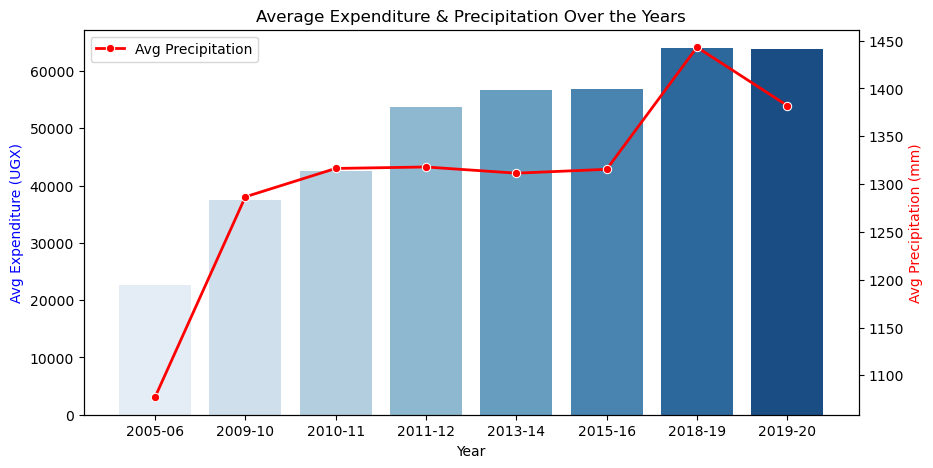

In [8]:
# Create a DataFrame for Expenditure
data = {
    'Year': ['2005-06', '2009-10', '2010-11', '2011-12', '2013-14', '2015-16', '2018-19', '2019-20'], 
    'Mean Expenditure': [mean_row_sum4, mean_row_sum2, mean_row_sum5, mean_row_sum3, mean_row_sum6, mean_row_sum1, mean_row_sum7, mean_row_sum8]
}
avgexp_df = pd.DataFrame(data)

# Create a DataFrame for Precipitation
precip_data = {
    'Year': ['2005-06', '2009-10', '2010-11', '2011-12', '2013-14', '2015-16', '2018-19', '2019-20'],
    'Avg Precipitation': [1077.08, 1286.69, 1316.37, 1317.90, 1311.43, 1315.45, 1443.16, 1382.07]  # Use values from new_precip_df
}
precip_df = pd.DataFrame(precip_data)

# Merge both DataFrames
merged_df = avgexp_df.merge(precip_df, on="Year")

# Plot bar chart for Mean Expenditure
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(x='Year', y='Mean Expenditure', data=merged_df, hue='Year', ax=ax1, palette='Blues', legend=False)

# Create secondary y-axis for Avg Precipitation
ax2 = ax1.twinx()
sns.lineplot(x='Year', y='Avg Precipitation', data=merged_df, ax=ax2, color='red', marker='o', linewidth=2, label="Avg Precipitation")

# Labels and title
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Expenditure (UGX)', color='blue')
ax2.set_ylabel('Avg Precipitation (mm)', color='red')
plt.title('Average Expenditure & Precipitation Over the Years')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()

### Visual: Average Consumption and Rainfall Comparison

In [9]:
#2005-06 total consumption for each good
tot_cons4 = ugd4_c.sum(axis=0)
#2009-10 total consumption for each good
tot_cons2 = ugd2_c.sum(axis=0)
#2010-11 total consumption for each good
tot_cons5 = ugd5_c.sum(axis=0)
#2011-12 total consumption for each good
tot_cons3 = ugd3_c.sum(axis=0)
#2013-14 total consumption for each good
tot_cons6 = ugd6_c.sum(axis=0)
#2015-16 total consumption for each good
tot_cons = ugd_c.sum(axis=0)
#2018-19 total consumption for each good
tot_cons7 = ugd7_c.sum(axis=0)
#2019-20 total consumption for each good
tot_cons8 = ugd8_c.sum(axis=0)

# Dictionary of total consumption series by year
total_consumption_by_year = {
    '2005-06': tot_cons4,
    '2009-10': tot_cons2,
    '2010-11': tot_cons5,
    '2011-12': tot_cons3,
    '2013-14': tot_cons6,
    '2015-16': tot_cons,
    '2018-19': tot_cons7,
    '2019-20': tot_cons8,
}

tot_cons8.sort_values(ascending=False).head(30)

j
Matoke                    15385.461953
Sweet Potatoes (fresh)     7971.156939
Cassava (fresh)            5974.434211
Tomatoes                   4943.278948
Maize (flour)              4607.761538
Cassava (dry)              4524.627635
Dodo                       4522.472493
Maize (cobs)               3624.715413
Mangos                     2935.135385
Beans (dry)                2781.788903
Avocado                    2160.009096
Eggplant                   2066.641015
Rice                       1922.248780
Irish Potatoes             1874.680414
Beans (fresh)              1528.571710
Onions                     1449.089278
Chapati                    1299.405772
Other Vegetables           1250.131291
Beef                       1236.440970
Oranges                    1080.806060
Kabalagala                 1079.520945
Cooking Oil (refined)       999.024629
Eggs                        913.650880
Restaurant (soda)           772.424391
Bread                       751.926688
Salt                   

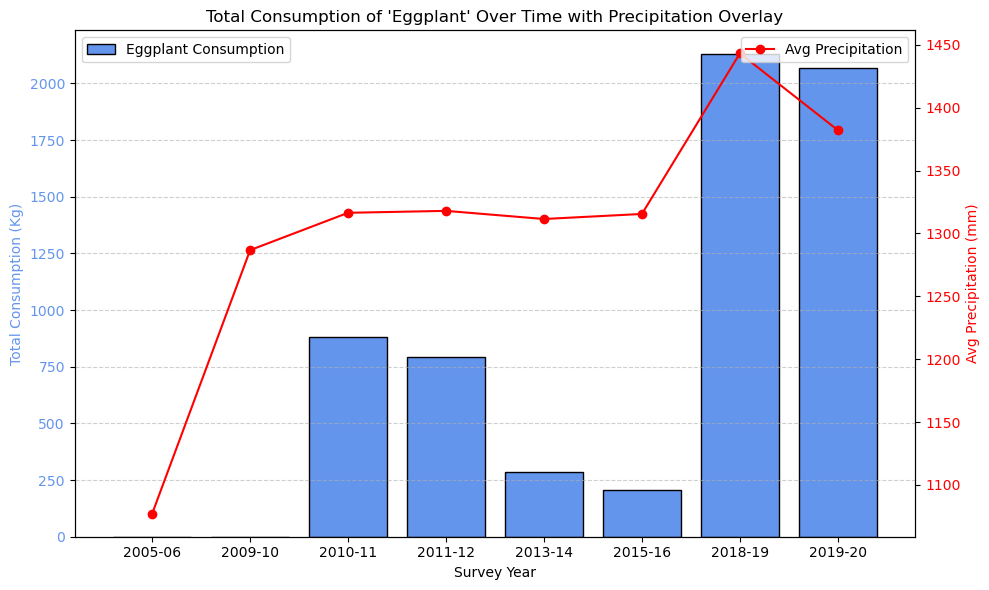

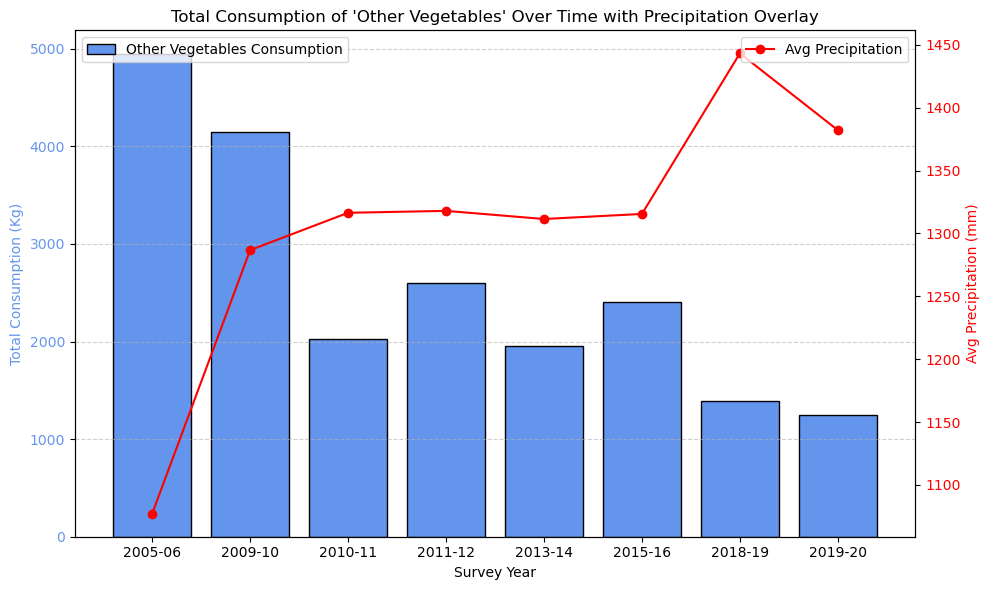

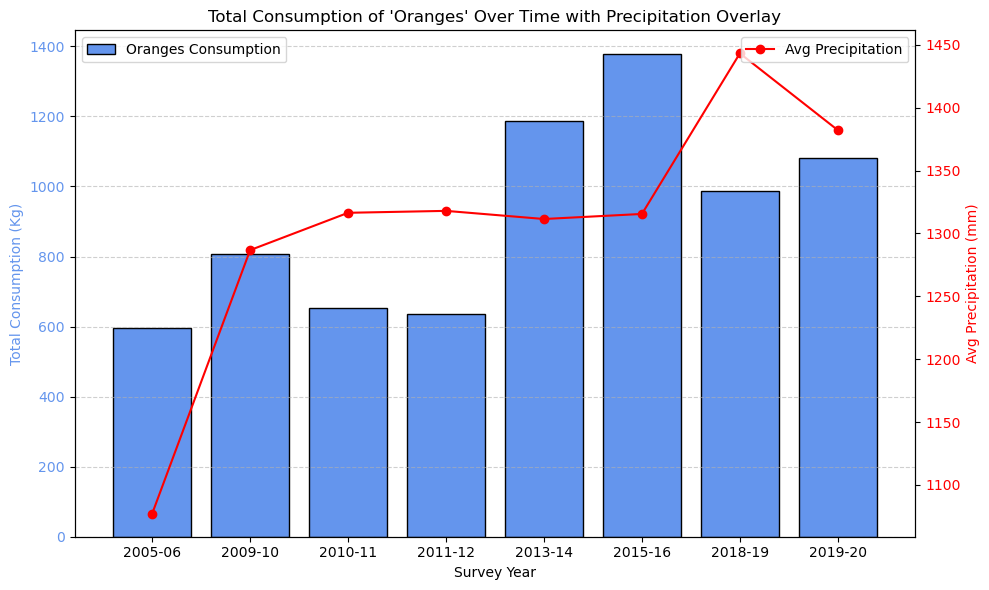

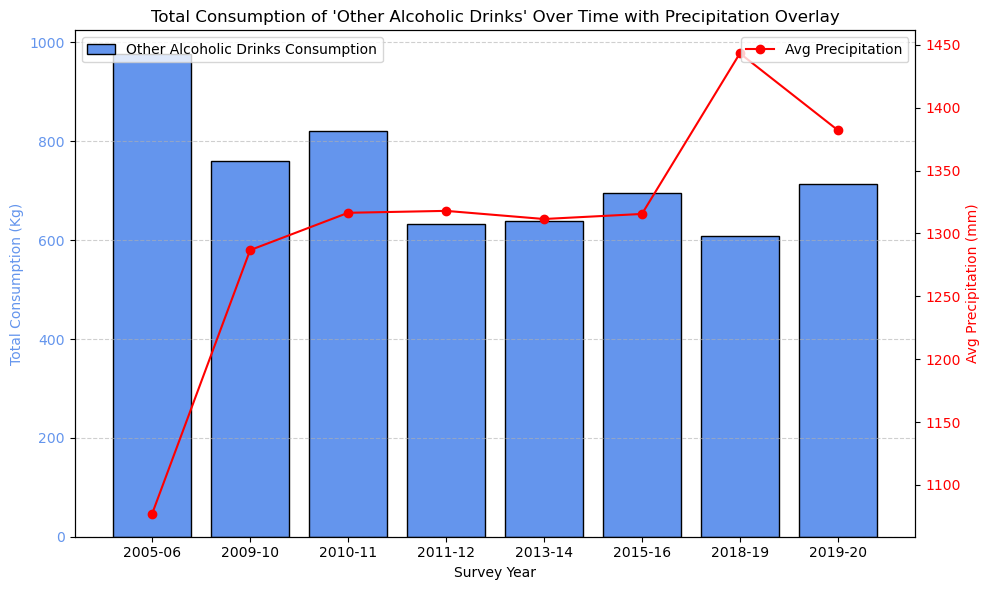

In [11]:
def plot_consumption_over_time(food_name):
    # Precipitation data
    precip_data = {
        'Year': ['2005-06', '2009-10', '2010-11', '2011-12', '2013-14', '2015-16', '2018-19', '2019-20'],
        'Avg Precipitation': [1077.08, 1286.69, 1316.37, 1317.90, 1311.43, 1315.45, 1443.16, 1382.07]
    }
    precip_df = pd.DataFrame(precip_data).set_index("Year")

    years = []
    values = []

    for year, series in total_consumption_by_year.items():
        years.append(year)
        values.append(series.get(food_name, 0))  # 0 if food not in year

    # Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Bar chart for food consumption
    ax1.bar(years, values, color='cornflowerblue', edgecolor='black', label=f"{food_name} Consumption")
    ax1.set_xlabel("Survey Year")
    ax1.set_ylabel("Total Consumption (Kg)", color='cornflowerblue')
    ax1.tick_params(axis='y', labelcolor='cornflowerblue')
    ax1.set_title(f"Total Consumption of '{food_name}' Over Time with Precipitation Overlay")
    ax1.grid(axis='y', linestyle='--', alpha=0.6)

    # Secondary y-axis for precipitation
    ax2 = ax1.twinx()
    ax2.plot(years, precip_df['Avg Precipitation'], color='red', marker='o', label='Avg Precipitation')
    ax2.set_ylabel("Avg Precipitation (mm)", color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_consumption_over_time('Eggplant')
plot_consumption_over_time('Other Vegetables')
#opposite
plot_consumption_over_time('Oranges')
plot_consumption_over_time('Other Alcoholic Drinks')
#opposite

### Visual: Beta Comparison over Wet/Dry

In [27]:
# Importing Results
import cfe
# 2005-06
ugd4_result = cfe.read_pickle('RGSN Files/Uganda05-06.rgsn')
# 2009-10
ugd2_result = cfe.read_pickle('RGSN Files/Uganda09-10.rgsn')
# 2010-11
ugd5_result = cfe.read_pickle('RGSN Files/Uganda10-11.rgsn')
#2011-12
ugd3_result = cfe.read_pickle('RGSN Files/Uganda11-12.rgsn')
#2013-14
ugd6_result = cfe.read_pickle('RGSN Files/Uganda13-14.rgsn')
#2015-16
ugd_result = cfe.read_pickle('RGSN Files/Uganda15-16.rgsn')
#2018-19
ugd7_result = cfe.read_pickle('RGSN Files/Uganda18-19.rgsn')
#2019-20
ugd8_result = cfe.read_pickle('RGSN Files/Uganda19-20.rgsn')

In [28]:
#Beta results as series
# 2005-06
ugd4_beta = ugd4_result.get_beta().sort_values(ascending=False)
# 2009-10
ugd2_beta = ugd2_result.get_beta().sort_values(ascending=False)
# 2010-11
ugd5_beta = ugd5_result.get_beta().sort_values(ascending=False)
#2011-12
ugd3_beta = ugd3_result.get_beta().sort_values(ascending=False)
#2013-14
ugd6_beta = ugd6_result.get_beta().sort_values(ascending=False)
#2015-16
ugd4_beta = ugd_result.get_beta().sort_values(ascending=False)
#2018-19
ugd7_beta = ugd7_result.get_beta().sort_values(ascending=False)
#2019-20
ugd8_beta = ugd8_result.get_beta().sort_values(ascending=False)

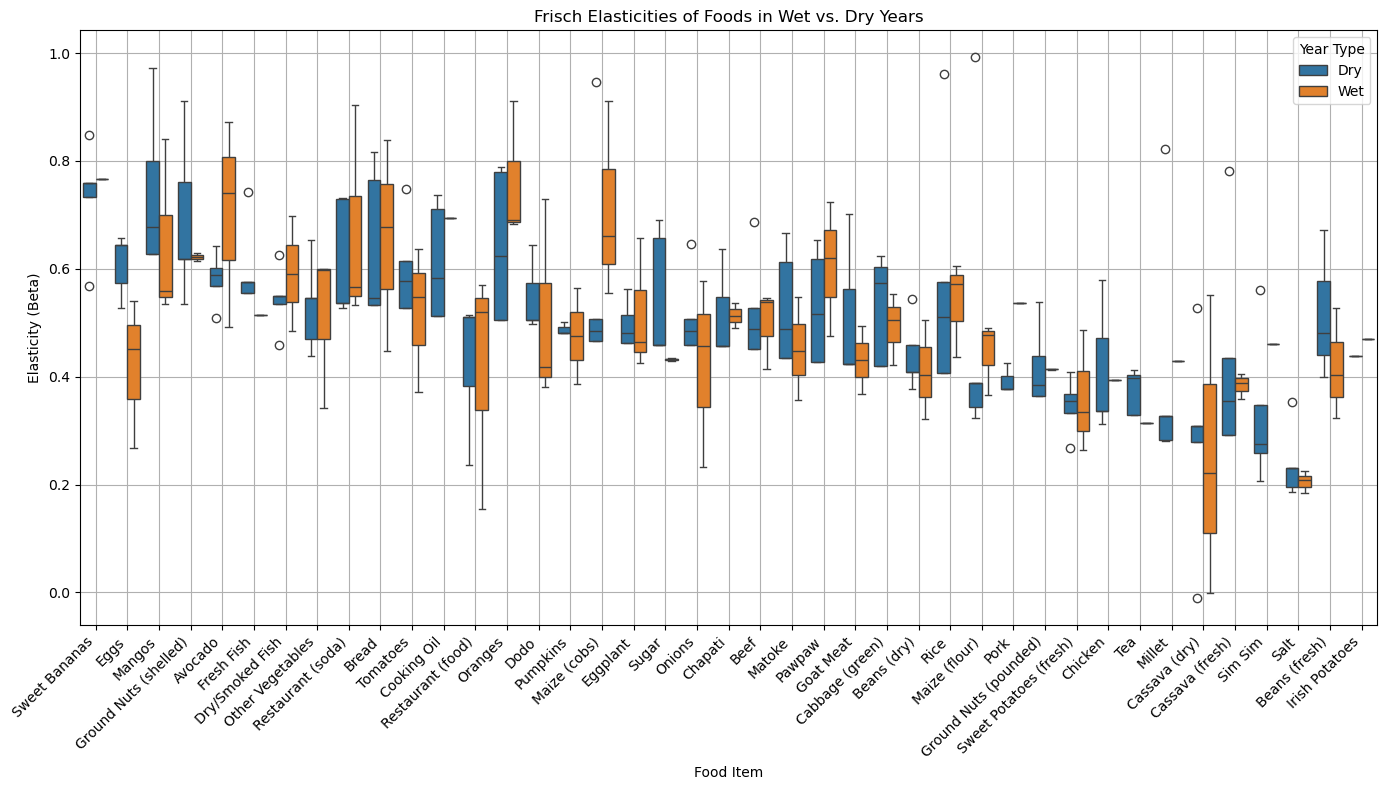

In [32]:
# Dictionary of beta values by year
beta_by_year = {
    '2005-06': ugd4_beta,
    '2009-10': ugd2_beta,
    '2010-11': ugd5_beta,
    '2011-12': ugd3_beta,
    '2013-14': ugd6_beta,
    '2015-16': ugd4_beta,
    '2018-19': ugd7_beta,
    '2019-20': ugd8_beta,
}

# Wet/Dry classification
wet_years = ['2011-12', '2018-19', '2019-20']
dry_years = ['2005-06', '2009-10', '2010-11', '2013-14', '2015-16']

# Flatten to long DataFrame with columns: Food, Beta, Year, Type (Wet/Dry)
rows = []
for year, series in beta_by_year.items():
    for food, beta in series.items():
        rows.append({
            'Food': food,
            'Beta': beta,
            'Year': year,
            'Type': 'Wet' if year in wet_years else 'Dry'
        })

beta_df = pd.DataFrame(rows)

# Optional: filter to foods that appear in both Wet and Dry
foods_in_both = beta_df.groupby('Food')['Type'].nunique()
common_foods = foods_in_both[foods_in_both == 2].index
filtered_df = beta_df[beta_df['Food'].isin(common_foods)]

# Plotting
plt.figure(figsize=(14, 8))
sns.boxplot(data=filtered_df, x='Food', y='Beta', hue='Type')
plt.xticks(rotation=45, ha='right')
plt.title('Frisch Elasticities of Foods in Wet vs. Dry Years')
plt.ylabel('Elasticity (Beta)')
plt.xlabel('Food Item')
plt.grid(True)
plt.tight_layout()
plt.legend(title='Year Type')
plt.show()

**Foods with Evident Differences**

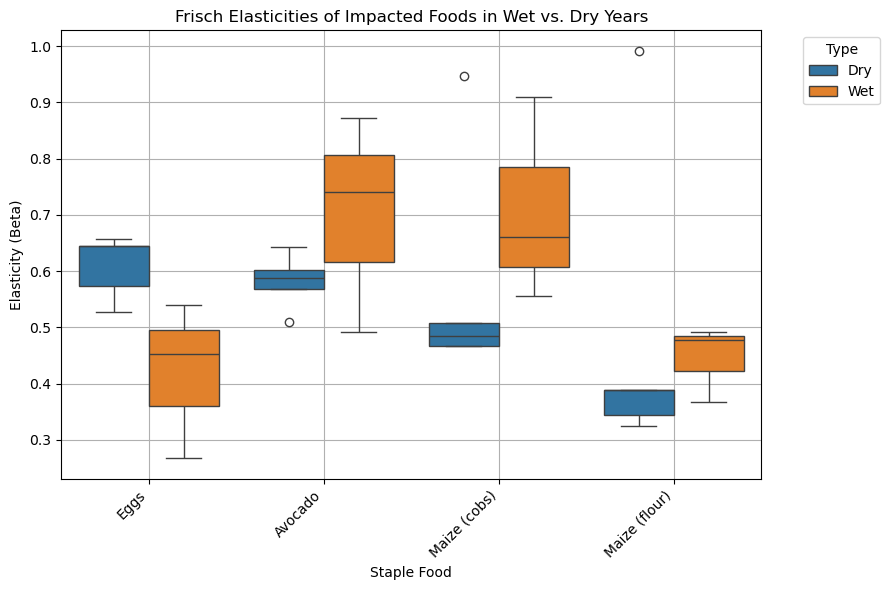

In [30]:
# Define staple foods
impacted_foods = ['Eggs', 'Maize (cobs)', 'Maize (flour)','Avocado']

# Create long-form DataFrame
rows = []
for year, series in beta_by_year.items():
    for food, beta in series.items():
        if food in impacted_foods:
            rows.append({
                'Food': food,
                'Beta': beta,
                'Year': year,
                'Type': 'Wet' if year in wet_years else 'Dry'
            })
df = pd.DataFrame(rows)

# Compute trendline values (mean per food & type)
trend_data = df.groupby(['Food', 'Type'])['Beta'].mean().reset_index()

# Plot
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='Food', y='Beta', hue='Type')
plt.title('Frisch Elasticities of Impacted Foods in Wet vs. Dry Years')
plt.xlabel('Staple Food')
plt.ylabel('Elasticity (Beta)')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Foods with Evident Similarities**

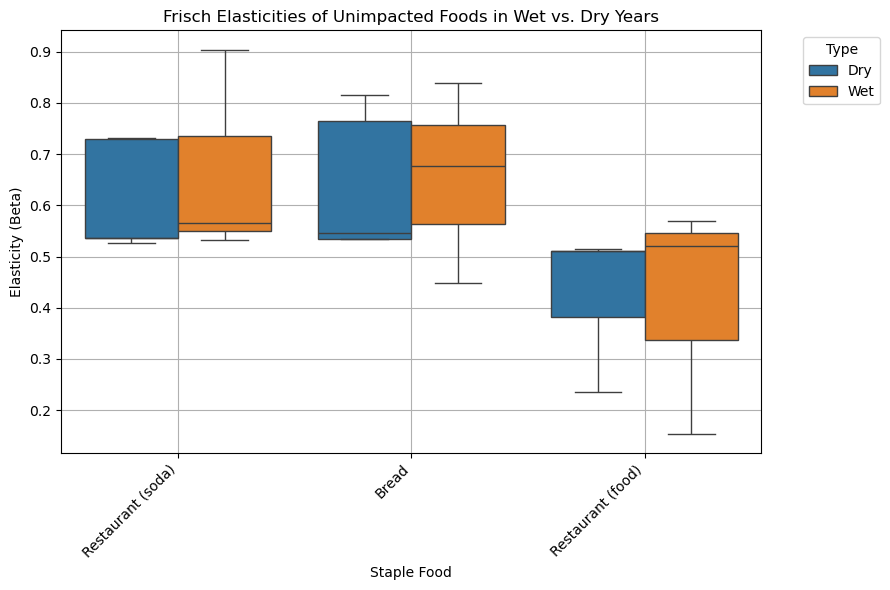

In [31]:
# Define staple foods
unimpacted_foods = ['Restaurant (food)', 'Restaurant (soda)', 'Bread']

# Create long-form DataFrame
rows = []
for year, series in beta_by_year.items():
    for food, beta in series.items():
        if food in unimpacted_foods:
            rows.append({
                'Food': food,
                'Beta': beta,
                'Year': year,
                'Type': 'Wet' if year in wet_years else 'Dry'
            })
df = pd.DataFrame(rows)

# Compute trendline values (mean per food & type)
trend_data = df.groupby(['Food', 'Type'])['Beta'].mean().reset_index()

# Plot
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='Food', y='Beta', hue='Type')
plt.title('Frisch Elasticities of Unimpacted Foods in Wet vs. Dry Years')
plt.xlabel('Staple Food')
plt.ylabel('Elasticity (Beta)')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Visual: Comparing Welfare with Precipitation

In [33]:
# Collect all results
all_results = []

for result in [ugd4_result, ugd2_result, ugd5_result, ugd3_result, ugd6_result, ugd_result, ugd7_result, ugd8_result]:
    w_series = result.get_w()
    df = w_series.reset_index()
    df.columns = ['household_id', 'year', 'region', 'welfare']
    all_results.append(df)

# Concatenate into a single DataFrame
welfare_df = pd.concat(all_results, ignore_index=True)

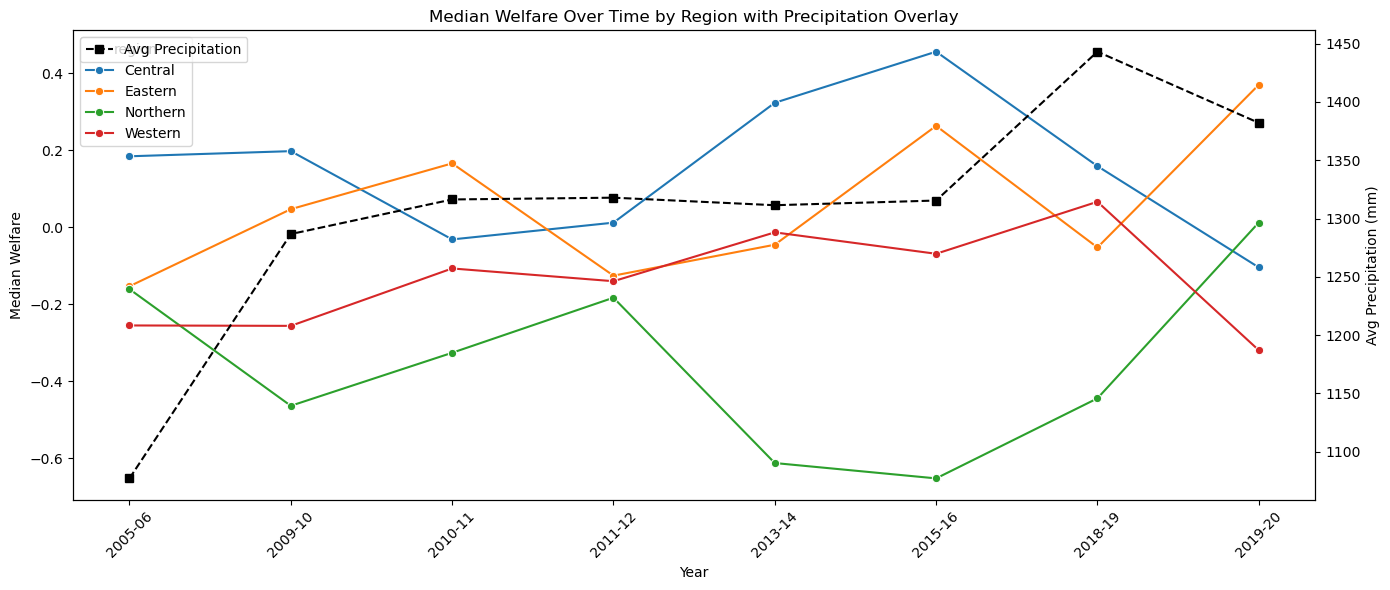

In [34]:
# Compute median welfare per region/year
median_df = welfare_df.groupby(['year', 'region'])['welfare'].median().reset_index()

# Plot median welfare by region
fig, ax1 = plt.subplots(figsize=(14, 6))

sns.lineplot(data=median_df, x='year', y='welfare', hue='region', marker='o', ax=ax1)
ax1.set_title("Median Welfare Over Time by Region with Precipitation Overlay")
ax1.set_xlabel("Year")
ax1.set_ylabel("Median Welfare")
ax1.tick_params(axis='x', rotation=45)

# Plot precipitation on a secondary y-axis
ax2 = ax1.twinx()
ax2.plot(precip_df['Year'], precip_df['Avg Precipitation'], color='black', linestyle='--', marker='s', label='Avg Precipitation')
ax2.set_ylabel("Avg Precipitation (mm)")
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

**Just Western Region:**

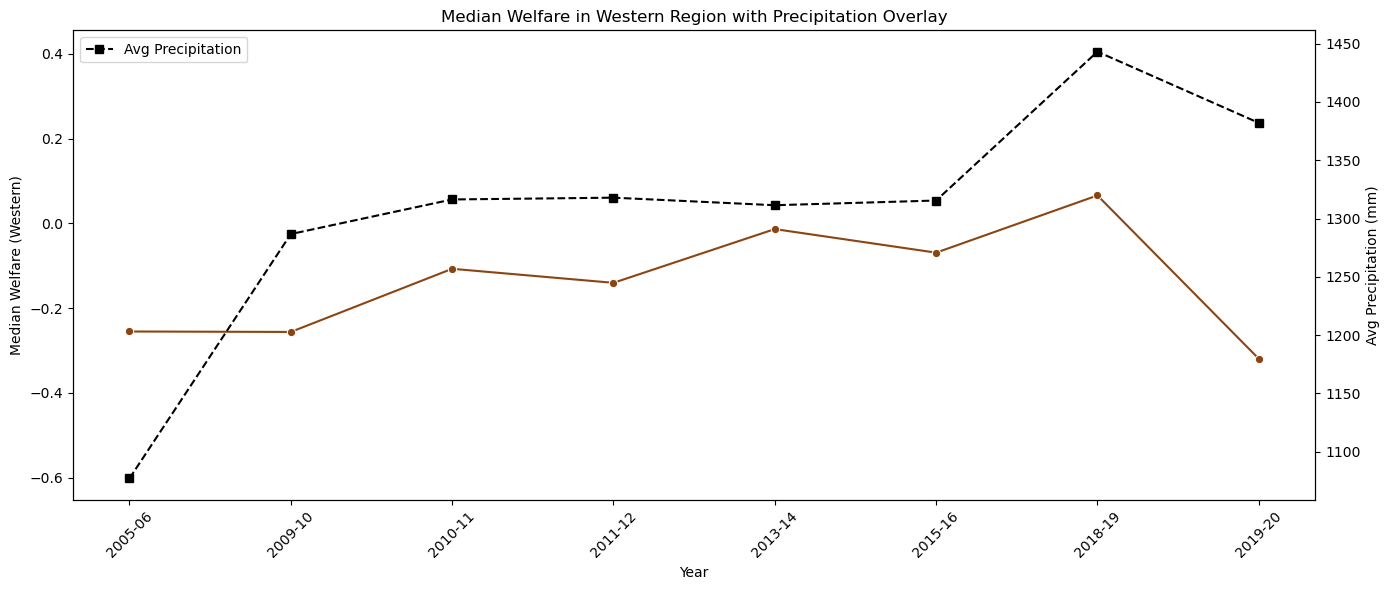

In [35]:
# First, find y-limits from the full-region plot
ymin = median_df['welfare'].min()
ymax = median_df['welfare'].max()

# Filter to just Western region
western_df = welfare_df[welfare_df['region'] == 'Western']

# Compute median welfare for Western region per year
western_median = western_df.groupby('year')['welfare'].median().reset_index()

# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

sns.lineplot(data=western_median, x='year', y='welfare', marker='o', color='saddlebrown', ax=ax1)
ax1.set_title("Median Welfare in Western Region with Precipitation Overlay")
ax1.set_xlabel("Year")
ax1.set_ylabel("Median Welfare (Western)")
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(ymin, ymax)  # Apply consistent y-axis scale

# Secondary axis for precipitation
ax2 = ax1.twinx()
ax2.plot(precip_df['Year'], precip_df['Avg Precipitation'], color='black', linestyle='--', marker='s', label='Avg Precipitation')
ax2.set_ylabel("Avg Precipitation (mm)")
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Visual: Wet/Dry Welfare Comparison

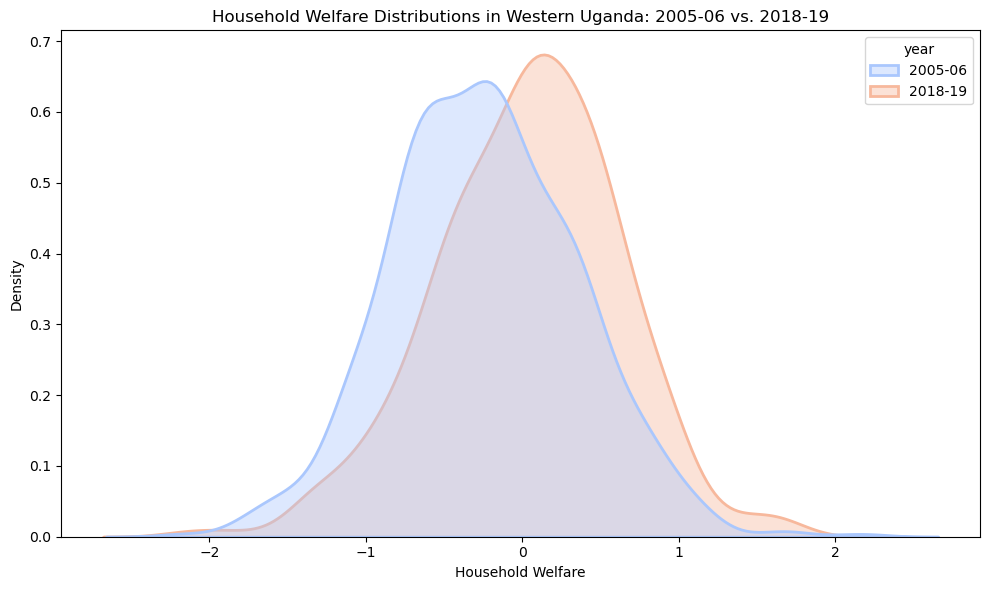

In [49]:
# Make sure 'Year' in wetdry_df and 'year' in welfare_df match format
wetdry_df.columns = ['year', 'precipitation', 'classification']

# Filter for Western region
welfare_classified_western = welfare_classified_filtered[welfare_classified_filtered['region'] == 'Western']

# Filter for Western region and 2005-06, 2018-19 years
welfare_classified_western_years = welfare_classified_western[welfare_classified_western['year'].isin(['2005-06', '2018-19'])]

# Plot
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=welfare_classified_western_years,
    x='welfare',
    hue='year',
    common_norm=False,
    fill=True,
    alpha=0.4,
    palette='coolwarm',
    linewidth=2
)

plt.title("Household Welfare Distributions in Western Uganda: 2005-06 vs. 2018-19")
plt.xlabel("Household Welfare")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

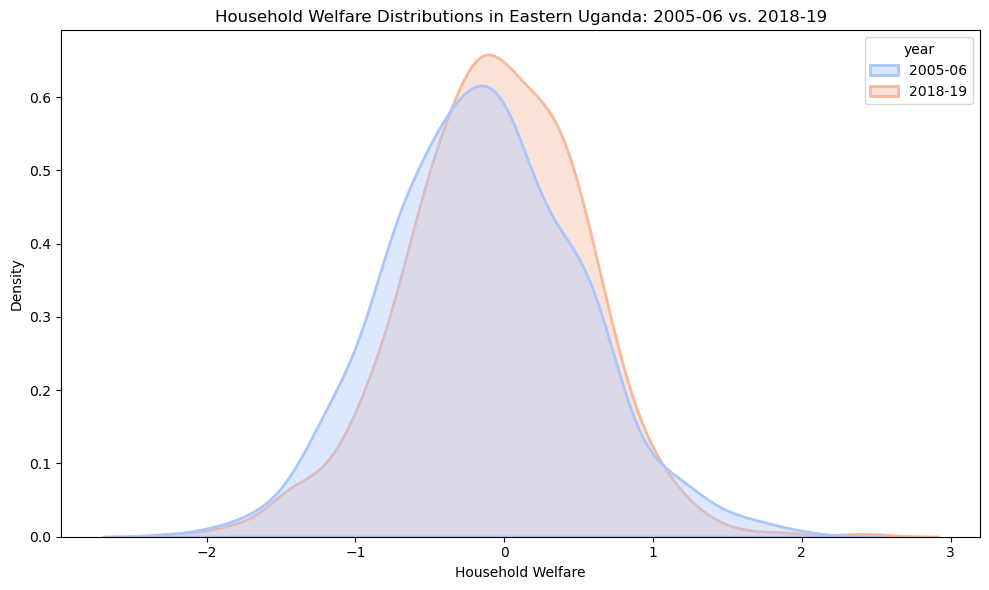

In [47]:
welfare_classified_eastern = welfare_classified_filtered[welfare_classified_filtered['region'] == 'Eastern']

# Filter for Western region and 2005-06, 2018-19 years
welfare_classified_eastern_years = welfare_classified_eastern[welfare_classified_eastern['year'].isin(['2005-06', '2018-19'])]

# Plot
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=welfare_classified_eastern_years,
    x='welfare',
    hue='year',
    common_norm=False,
    fill=True,
    alpha=0.4,
    palette='coolwarm',
    linewidth=2
)

plt.title("Household Welfare Distributions in Eastern Uganda: 2005-06 vs. 2018-19")
plt.xlabel("Household Welfare")
plt.ylabel("Density")
plt.tight_layout()
plt.show()